In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from IPython.display import Image

In [3]:
class State(TypedDict):
    name : str
    gold : int
    has_armor : bool
    status: Literal['arrived', 'not_arrived']
    has_shield : bool
    has_weapon: bool

In [4]:
def check_inventory(state: State) -> State:
    print("Checking inventory...")
    return state 
def check_inventory_condition(state: State) -> Literal['enter_tourney', 'seek_merchant']:
    if state['gold'] >= 100 and state['has_armor'] and state['has_shield'] and state['has_weapon']:
        return 'enter_tourney'
    else:
        return 'seek_merchant'
    
def enter_tourney(state: State) -> State:
    return {'status': 'arrived'}

def seek_merchant(state: State) -> State:
    return {'gold': state['gold'] + 50, 'has_armor': True, 'has_shield': True, 'has_weapon': True}

In [5]:
graph = StateGraph(State)
graph.add_node("check_inventory", check_inventory)
graph.add_node("enter_tourney", enter_tourney)
graph.add_node("seek_merchant", seek_merchant)

graph.add_edge(START, "check_inventory")
graph.add_conditional_edges("check_inventory", check_inventory_condition)
graph.add_edge("enter_tourney", END)
graph.add_edge("seek_merchant", END)

final = graph.compile()

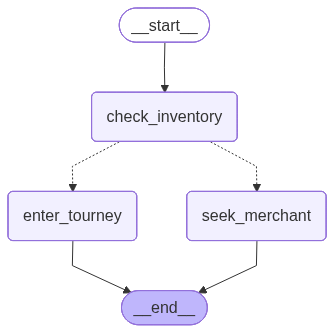

In [8]:
Image(final.get_graph().draw_mermaid_png())